# **Image Inpainting** with **LangSAM** and **Stable Diffusion:**

### The **lang-segment-anything** library presents an innovative approach to object detection and segmentation by combining the strengths of **GroundingDino** and **SAM**. SAM’s default image encoder is **ViT-H**, but it can also utilize ViT-L or ViT-B depending on the specific requirements


In [1]:
!pip install -U git+https://github.com/luca-medeiros/lang-segment-anything.git

  Cloning https://github.com/luca-medeiros/lang-segment-anything.git to /tmp/pip-req-build-sd1tpzwj
  Running command git clone --filter=blob:none --quiet https://github.com/luca-medeiros/lang-segment-anything.git /tmp/pip-req-build-sd1tpzwj
  Resolved https://github.com/luca-medeiros/lang-segment-anything.git to commit 918043ed4666eea04da88aa179eb8d27ef4b1a1d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/facebookresearch/segment-anything-2 (to revision c2ec8e14a185632b0a5d8b161928ceb50197eddc) to /tmp/pip-install-g_830m3p/sam-2_420403594f0c4b52a46b6fc4681886da
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything-2 /tmp/pip-install-g_830m3p/sam-2_420403594f0c4b52a46b6fc4681886da
  Running command git rev-parse -q --verify 'sha^c2ec8e14a185632b0a5d8b161928ceb50197eddc'
  Running command git fetch -q https://github.co

## **Diffusers** library for **Inpainting** the segmented are based on Target-Prompt.

In [2]:
!pip install diffusers transformers accelerate scipy safetensors

### Dependencies

In [3]:
from PIL import Image
from lang_sam import LangSAM
from lang_sam.utils import draw_image
from diffusers import StableDiffusionInpaintPipeline
import matplotlib.pyplot as plt
import torch
import numpy as np

/usr/local/lib/python3.12/dist-packages/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
# Check and set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Initialize **LangSAM** model for object segmentation

In [5]:
model = LangSAM()

Downloading: "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt" to /root/.cache/torch/hub/checkpoints/sam2.1_hiera_small.pt


100%|██████████| 176M/176M [00:00<00:00, 219MB/s]


One or both local paths not provided. Loading from Hugging Face Hub: IDEA-Research/grounding-dino-base


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

### Initialize **StableDiffusionInpaintPipeline** model for image inpainting

In [6]:
inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "sd-legacy/stable-diffusion-inpainting",
    torch_dtype=torch.float16)

inpaint.to(device)

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models

StableDiffusionInpaintPipeline {
  "_class_name": "StableDiffusionInpaintPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "sd-legacy/stable-diffusion-inpainting",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

### End-to-end Pipeline


In [7]:
# Function to process image, perform segmentation, and inpainting

def final_pipeline(image_pil, Source_prompt, Target_prompt):

    # Step 1: LangSAM predict
    results = model.predict(image_pil, Source_prompt)
    result = results[0]

    masks = result["masks"]
    boxes = result["boxes"]
    labels = result["labels"]
    logits = result["scores"]
    mask_scores = result['mask_scores']

    # Step 2: Select best mask based on LangSAM masking
    best_idx = np.argmax(mask_scores)
    mask = masks[best_idx]

    # Step 3: Convert mask to PIL Image
    mask = (mask > 0.5).astype(np.uint8) * 255
    mask_pil = Image.fromarray(mask)

    # Step 4: Perform inpainting with StableDiffusionInpaintPipeline
    inpainted_image = inpaint(prompt=Target_prompt, image=image_pil, mask_image=mask_pil).images[0]

    # Step 5: Putting mask on Image for showing Comparison
    overlay = np.array(image_pil).copy()
    if overlay.ndim == 4:
      overlay = overlay[0]
    overlay[mask == 255] = [0, 0, 0]
    overlay_pil = Image.fromarray(overlay)

    return inpainted_image, overlay_pil

### Function to plot Original image, Mask, Inpainted image

In [8]:
def plot(image_pil, inpainted_image, mask):
  fig, axes = plt.subplots(1, 3, figsize=(12, 6))

  # Plot original image with masks
  axes[0].imshow(image_pil)
  axes[0].set_title('Original Image')

  # Plot inpainted image
  axes[2].imshow(inpainted_image)
  axes[2].set_title('Inpainted Image')

  # Plot Mask
  axes[1].imshow(mask)
  axes[1].set_title('Mask')

  # Hide axes ticks for cleaner visualization
  for ax in axes:
      ax.axis('off')

  # Adjust layout and display images
  plt.tight_layout()
  plt.show()


### EXAMPLE 1


Predicting 1 masks


Predicted 1 masks


  0%|          | 0/50 [00:00<?, ?it/s]

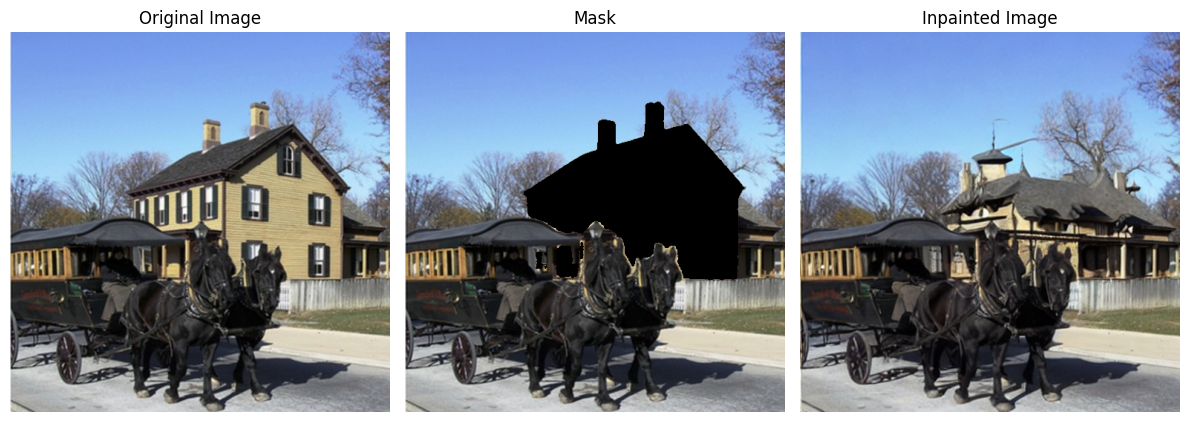

In [9]:
image_pil = Image.open('/content/Screenshot 2024-06-25 114812.png').convert("RGB").resize((512, 512))
Source_prompt = 'House'
Target_prompt = "middle-age Castle"
inpainted_image, mask = final_pipeline([image_pil], [Source_prompt], Target_prompt)

plot(image_pil, inpainted_image, mask)

### EXAMPLE 2



Predicting 1 masks
Predicted 1 masks


  0%|          | 0/50 [00:00<?, ?it/s]

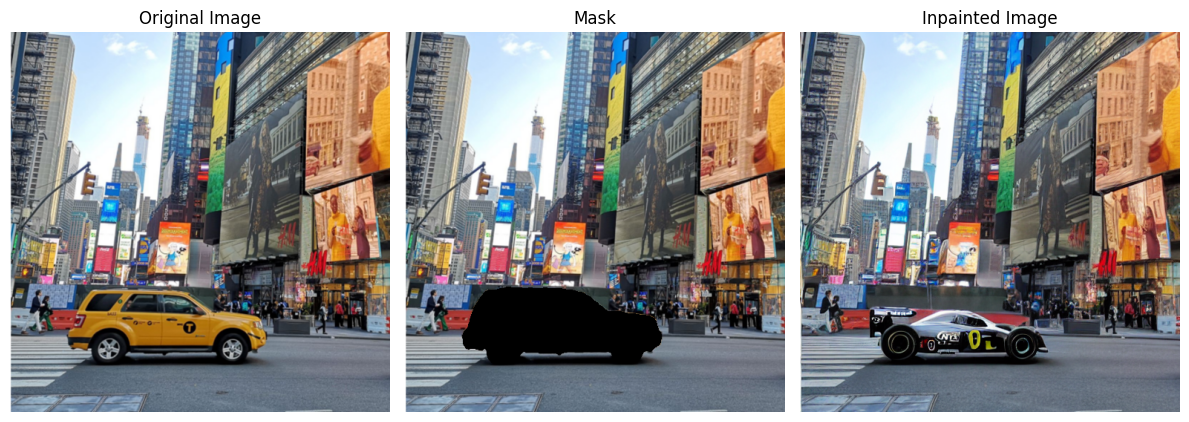

In [20]:
image_pil = Image.open('/content/Screenshot 2026-05-04 124403.png').convert("RGB").resize((512, 512))
Source_prompt = 'Car'
Target_prompt = "Race Car"
inpainted_image, mask = final_pipeline([image_pil], [Source_prompt], Target_prompt)

plot(image_pil, inpainted_image, mask)